In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Altere somente este nome para analisar outro ensaio.
ARQUIVO_CSV = "dadosV2.csv"
FUSO_HORARIO = "America/Sao_Paulo"

# Preserva a coleta original para conferência.
df_bruto = pd.read_csv(ARQUIVO_CSV)

In [ ]:
# field1 é a vazão informada pelo ESP32; field2 é o volume acumulado.
df = df_bruto[['created_at', 'field1', 'field2']].copy()
df.columns = ['Data', 'VazaoESP32', 'VolumeAcumulado']

df['Data'] = pd.to_datetime(df['Data'], utc=True, errors='coerce')
datas_invalidas = int(df['Data'].isna().sum())
df = df.dropna(subset=['Data']).copy()
df['Data'] = df['Data'].dt.tz_convert(FUSO_HORARIO)
df = df.sort_values('Data', kind='stable').reset_index(drop=True)

for coluna in ['VazaoESP32', 'VolumeAcumulado']:
    df[coluna] = pd.to_numeric(df[coluna], errors='coerce')
    df[coluna] = df[coluna].replace([np.inf, -np.inf], np.nan)

# Usa o intervalo real entre registros, que pode ser diferente de 20 segundos.
df['TempoMinutos'] = df['Data'].diff().dt.total_seconds() / 60
df['VolumeIntervalo'] = df['VolumeAcumulado'].diff()
df['ContadorReduziu'] = df['VolumeIntervalo'] < 0

# Não escolhe arbitrariamente um dos registros com a mesma data.
df['DataDuplicada'] = df['Data'].duplicated(keep=False)
volume_valido = (
    (df['VolumeAcumulado'] >= 0) &
    (df['VolumeAcumulado'].shift() >= 0)
)
datas_unicas = (
    ~df['DataDuplicada'] &
    ~df['DataDuplicada'].shift(fill_value=False)
)
df['IntervaloValido'] = (
    (df['TempoMinutos'] > 0) &
    (df['VolumeIntervalo'] >= 0) &
    volume_valido & datas_unicas
)

# Solução temporária: vazão MÉDIA no intervalo, em L/min.
# Não divide por 7,5: o volume já foi convertido para litros no ESP32.
df['vazao'] = (df['VolumeIntervalo'] / df['TempoMinutos']).where(
    df['IntervaloValido']
)
df['Dia'] = df['Data'].dt.date

# Mantém os intervalos inválidos como NaN: eles interrompem as linhas dos gráficos.
# Zeros válidos são preservados; podem representar ausência de fluxo.
print(f"Leituras: {len(df)} | Intervalos válidos: {df['IntervaloValido'].sum()}")
print(f"Datas inválidas: {datas_invalidas} | Reduções do contador: {df['ContadorReduziu'].sum()}")

In [12]:
#Limites aceitaveis da vazão
LIE = 10 #Limite mínimo
LSE = 20 #Limite máximo

#Classificação
df['NaoConforme'] = (
    (df['vazao'] < LIE) |
    (df['vazao'] > LSE)
).astype(int)

In [ ]:
# Limites de ESPECIFICAÇÃO, quando o requisito do ensaio for definido.
# Os antigos valores 10 e 20 eram exemplos; ficam desativados por enquanto.
LIE = None
LSE = None

if (LIE is None) != (LSE is None):
    raise ValueError("Defina LIE e LSE juntos, ou deixe ambos como None.")

df['NaoConforme'] = pd.Series(pd.NA, index=df.index, dtype='Int64')
if LIE is not None:
    if not (np.isfinite(LIE) and np.isfinite(LSE) and LIE < LSE):
        raise ValueError("LIE e LSE devem ser finitos, com LIE menor que LSE.")
    validos = df['vazao'].notna()
    df.loc[validos, 'NaoConforme'] = (
        (df.loc[validos, 'vazao'] < LIE) |
        (df.loc[validos, 'vazao'] > LSE)
    ).astype(int)

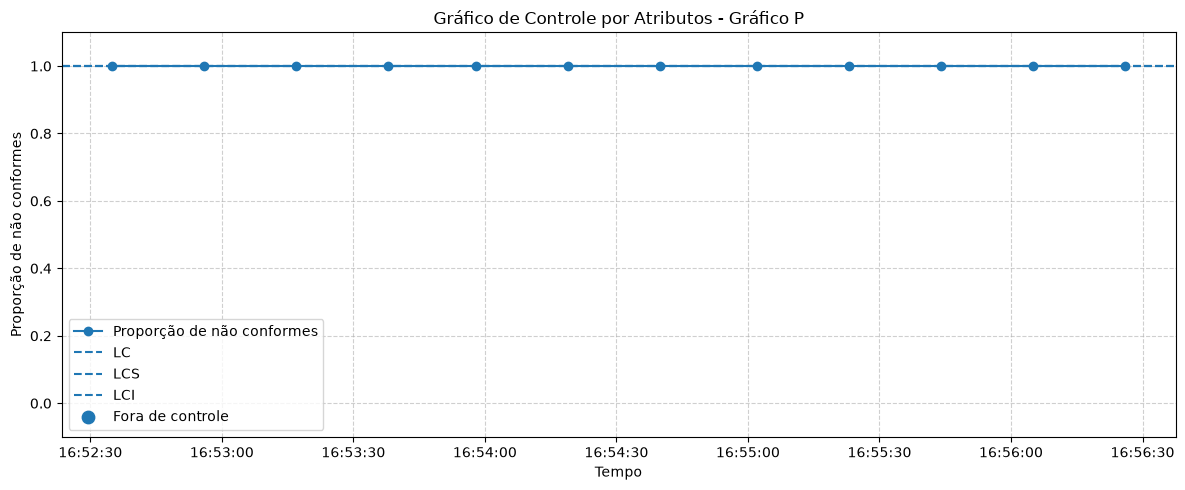

In [ ]:
# Calcula antes de remover qualquer NaN, para não atravessar intervalos inválidos.
df['MR'] = df['vazao'].diff().abs()
vazoes_validas = df['vazao'].dropna()
amplitudes_validas = df['MR'].dropna()

if len(vazoes_validas) < 2 or amplitudes_validas.empty:
    raise ValueError("São necessárias pelo menos duas vazões consecutivas válidas para I-MR.")

media_vazao = vazoes_validas.mean()
media_MR = amplitudes_validas.mean()
sigma_estimado = media_MR / 1.128

LC_I = media_vazao
LCI_I = media_vazao - 3 * sigma_estimado
LCS_I = media_vazao + 3 * sigma_estimado

LC_MR = media_MR
LCI_MR = 0.0
LCS_MR = 3.267 * media_MR

df['SinalI'] = (df['vazao'] < LCI_I) | (df['vazao'] > LCS_I)
df['SinalMR'] = (df['MR'] < LCI_MR) | (df['MR'] > LCS_MR)

limites = pd.DataFrame({
    'Carta': ['I', 'MR'],
    'LCI': [LCI_I, LCI_MR],
    'LC': [LC_I, LC_MR],
    'LCS': [LCS_I, LCS_MR],
})
print("Limites exploratórios (L/min):")
print(limites.round(3).to_string(index=False))
print(f"Sinais I: {df['SinalI'].sum()} | Sinais MR: {df['SinalMR'].sum()}")
if media_MR == 0:
    print("Aviso: amplitude média zero; os limites colapsam. Colete mais dados para avaliar a variabilidade.")

In [ ]:
fig, eixos = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

cartas = [
    ('vazao', 'SinalI', LC_I, LCI_I, LCS_I, 'Carta I — vazão média entre registros'),
    ('MR', 'SinalMR', LC_MR, LCI_MR, LCS_MR, 'Carta MR — amplitude móvel'),
]

for eixo, (coluna, sinal, lc, lci, lcs, titulo) in zip(eixos, cartas):
    eixo.plot(df['Data'], df[coluna], marker='o', markersize=5,
              linewidth=1.5, color='#1d4ed8', label='Medições')
    eixo.axhline(lc, color='#0f766e', linestyle='--', label=f'LC = {lc:.2f}')
    eixo.axhline(lcs, color='#d97706', linestyle='--', label=f'LCS = {lcs:.2f}')
    eixo.axhline(lci, color='#d97706', linestyle=':', label=f'LCI = {lci:.2f}')
    eixo.scatter(df.loc[df[sinal], 'Data'], df.loc[df[sinal], coluna],
                 color='#dc2626', s=70, zorder=5, label='Sinal estatístico')
    eixo.set_title(titulo, loc='left')
    eixo.set_ylabel('L/min')
    eixo.grid(True, linestyle='--', alpha=0.3)
    eixo.legend(loc='lower right', bbox_to_anchor=(1, 1.015),
                ncol=3, fontsize=8, frameon=False)

eixos[1].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
eixos[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S', tz=df['Data'].dt.tz))
eixos[1].set_xlabel(f"Tempo ({FUSO_HORARIO})")
fig.suptitle('Cartas I-MR | Limites exploratórios do ensaio', fontsize=14)
fig.text(0.5, 0.015, 'Limites de controle não são limites de especificação. A torneira foi alterada no ensaio.',
         ha='center', fontsize=9, color='#475569')
fig.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

In [ ]:
# Resumos calculados com a mesma vazão média usada nas cartas.
df_validos = df.loc[df['IntervaloValido']]
estatisticas_diarias = df_validos.groupby('Dia').agg(
    MediaDiaria=('vazao', 'mean'),
    Maxima=('vazao', 'max'),
    Minima=('vazao', 'min'),
    VolumeObservado=('VolumeIntervalo', 'sum'),
    TempoObservadoMin=('TempoMinutos', 'sum'),
).reset_index()

# Média ponderada pelo tempo, útil quando os intervalos de envio variam.
estatisticas_diarias['VazaoMediaTempo'] = (
    estatisticas_diarias['VolumeObservado'] /
    estatisticas_diarias['TempoObservadoMin']
)
df_final = pd.merge(df, estatisticas_diarias, on='Dia', how='left', sort=False)

In [ ]:
df_final['Media'] = df_final['vazao'].mean()
dia_pico_maximo = estatisticas_diarias.loc[estatisticas_diarias['Maxima'].idxmax(), 'Dia']
dia_pico_minimo = estatisticas_diarias.loc[estatisticas_diarias['Minima'].idxmin(), 'Dia']

----------------- Resumo Estatístico da Vazão ---------------------
count    12.000000
mean      5.762874
std       1.791703
min       2.558714
25%       4.158736
50%       6.574586
75%       7.120600
max       7.539990
Name: vazao, dtype: float64


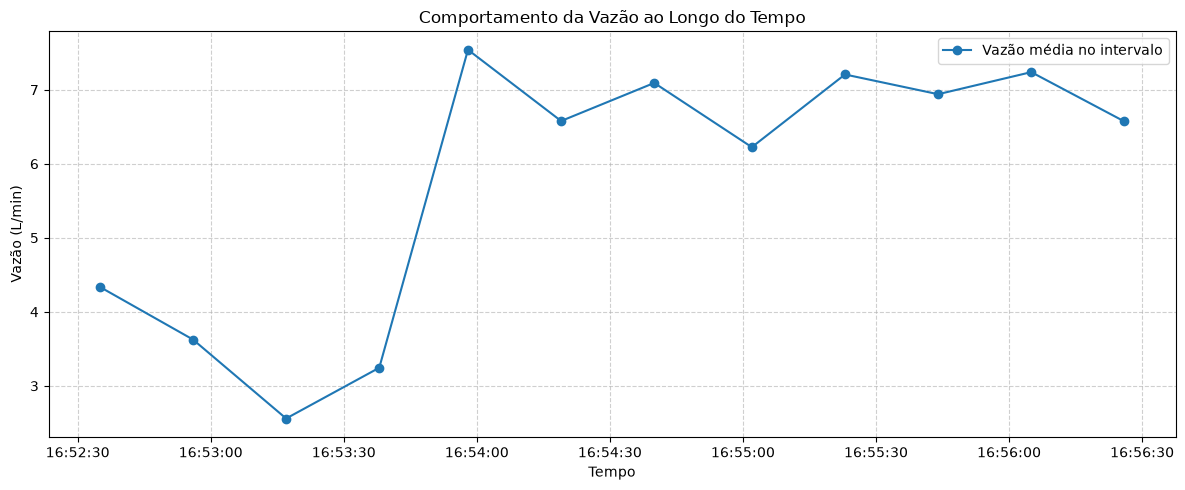

In [ ]:
fig, eixo = plt.subplots(figsize=(13, 5))
eixo.plot(df_final['Data'], df_final['vazao'], marker='o', linewidth=1.5,
          color='#1d4ed8', label='Vazão média pelo volume / tempo')
eixo.plot(df_final['Data'], df_final['VazaoESP32'], linestyle='--', alpha=0.7,
          color='#64748b', label='Última vazão informada pelo ESP32')

if LIE is not None:
    eixo.axhline(LIE, color='#d97706', linestyle=':', label='LIE (especificação)')
    eixo.axhline(LSE, color='#d97706', linestyle=':', label='LSE (especificação)')

eixo.set_title('Histórico da vazão — comparação de medidas', pad=38)
eixo.set_xlabel(f"Tempo ({FUSO_HORARIO})")
eixo.set_ylabel('Vazão (L/min)')
eixo.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
eixo.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S', tz=df_final['Data'].dt.tz))
eixo.grid(True, linestyle='--', alpha=0.3)
eixo.legend(loc='lower left', bbox_to_anchor=(0, 1.01),
            ncol=2, fontsize=9, frameon=False)
fig.text(0.5, 0.01, 'As curvas representam intervalos de medição diferentes; divergências não indicam automaticamente erro.',
         ha='center', fontsize=9, color='#475569')
fig.tight_layout(rect=[0, 0.045, 1, 1])
plt.show()

In [ ]:
print("Resumo da vazão média entre registros (L/min):")
print(df_final['vazao'].describe().round(3))
print("\nResumo diário — horário local:")
print(estatisticas_diarias.round(3).to_string(index=False))
print("\nVolume observado inclui somente intervalos válidos; não estima o consumo durante reinícios ou lacunas inválidas.")
if LIE is None:
    print("Especificação ainda não definida: classificação de conformidade desativada.")
else:
    print(f"Especificação: {LIE} a {LSE} L/min | Não conformes: {df_final['NaoConforme'].sum()}")